<a href="https://colab.research.google.com/github/abcdon21/trader-sentiment-analysis/blob/main/TraderPerformance_vs_MarketSentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# from google.colab import files

# uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv


In [4]:
# from google.colab import files

# uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
trade = pd.read_csv("historical_data.csv")
fg = pd.read_csv("fear_greed_index.csv")

DATA PREPROCESSING

In [6]:
trade.head()
trade.info()
trade.describe()
trade.shape
trade.isnull().sum()
trade.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

np.int64(0)

In [7]:
fg.head()
fg.info()
fg.describe()
fg.shape
fg.isnull().sum()
fg.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


np.int64(0)

In [8]:
trade.drop_duplicates(inplace=True)

In [9]:
trade.drop_duplicates(inplace=True)

VISUALIZATION

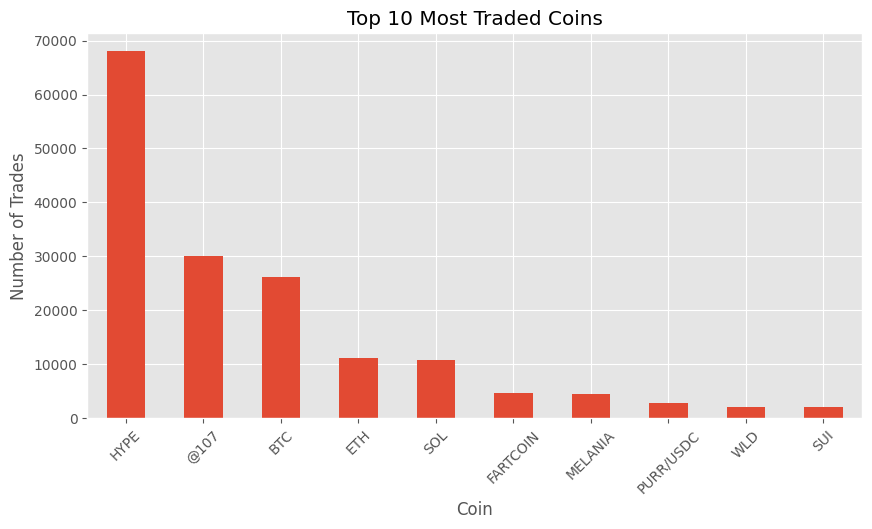

In [11]:
plt.figure(figsize=(10,5))

trade["Coin"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

Average Profit by Coin

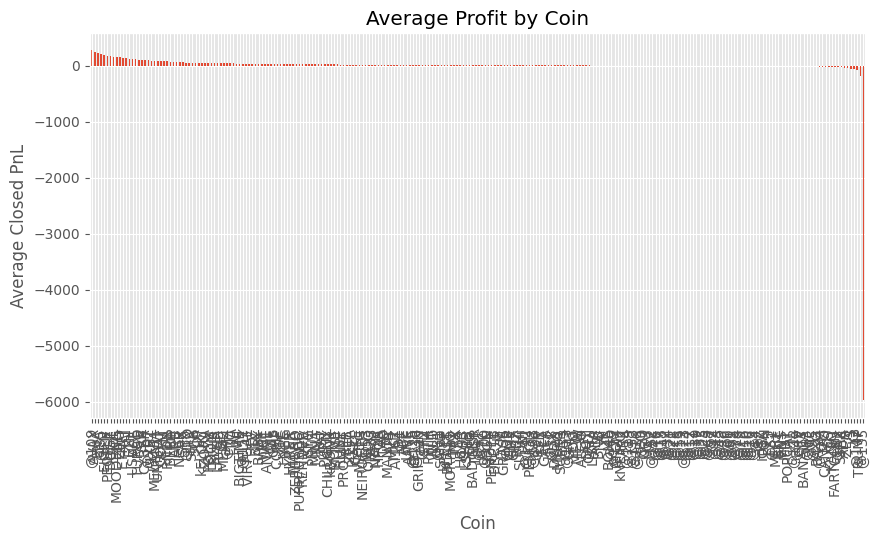

In [13]:
coin_profit = trade.groupby("Coin")["Closed PnL"].mean()

coin_profit.sort_values(ascending=False)

plt.figure(figsize=(10,5))

coin_profit.sort_values(ascending=False).plot(kind="bar")

plt.title("Average Profit by Coin")
plt.ylabel("Average Closed PnL")
plt.show()

Average Profit by Trade Side

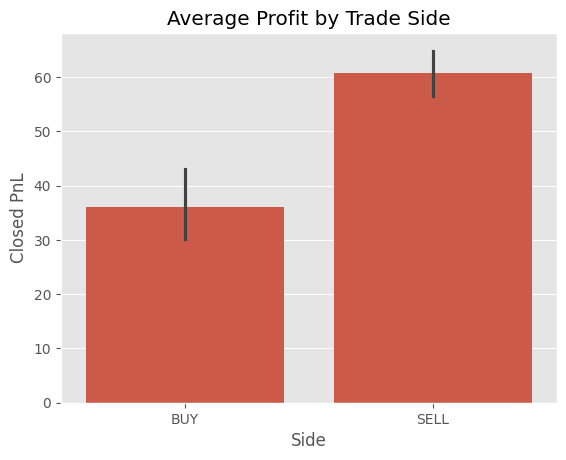

In [16]:
trade.groupby("Side")["Closed PnL"].mean()
sns.barplot(
    data=trade,
    x="Side",
    y="Closed PnL",
    estimator="mean"
)

plt.title("Average Profit by Trade Side")
plt.show()

Trading Volume by Coin

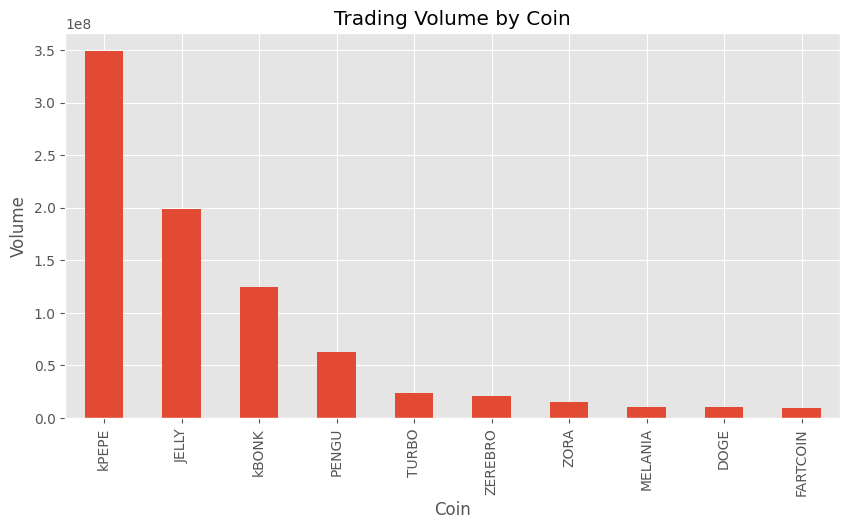

In [18]:
trade.groupby("Coin")["Size Tokens"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))

trade.groupby("Coin")["Size Tokens"]\
.sum()\
.sort_values(ascending=False)\
.head(10)\
.plot(kind="bar")

plt.title("Trading Volume by Coin")
plt.ylabel("Volume")
plt.show()

Execution Price Distribution

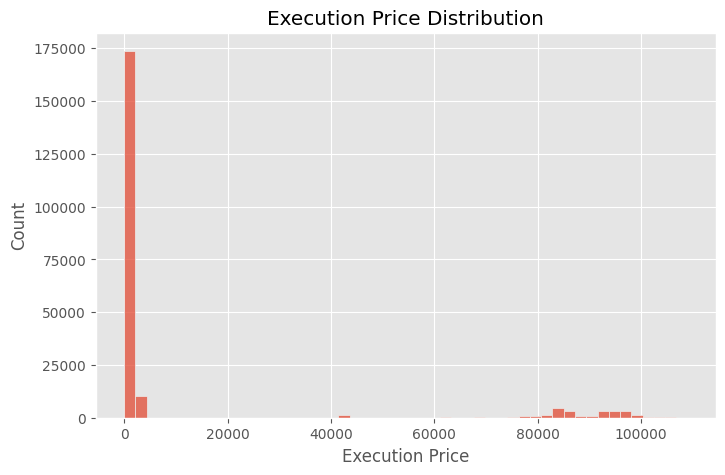

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(trade["Execution Price"], bins=50)

plt.title("Execution Price Distribution")
plt.show()

Fee Distribution

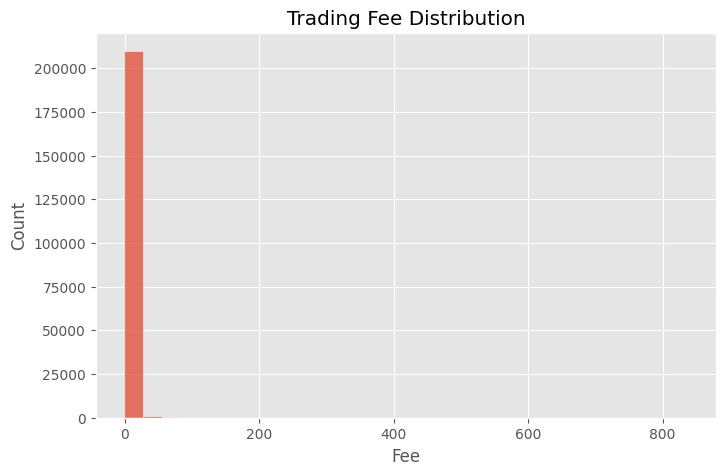

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(trade["Fee"], bins=30)

plt.title("Trading Fee Distribution")
plt.show()

Sentiment Distribution

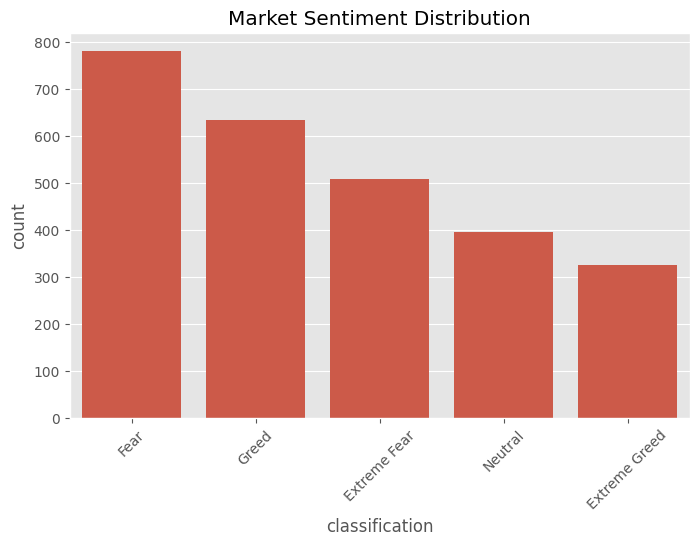

In [23]:
fg["classification"].value_counts()
plt.figure(figsize=(8,5))

sns.countplot(
    data=fg,
    x="classification",
    order=fg["classification"].value_counts().index
)

plt.title("Market Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()


Fear & Greed Score Distribution

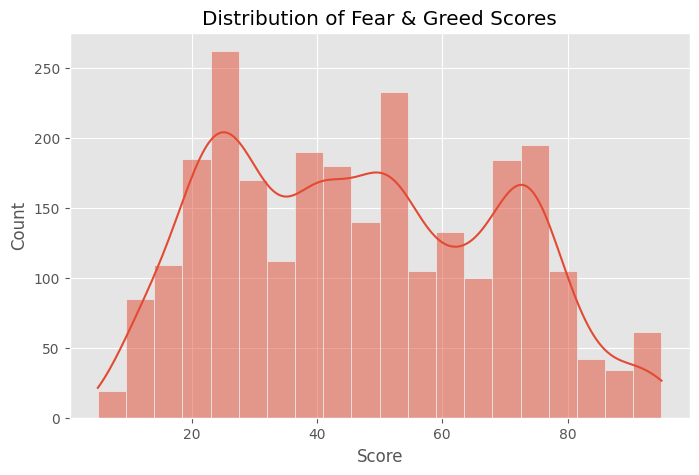

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    fg["value"],
    bins=20,
    kde=True
)

plt.title("Distribution of Fear & Greed Scores")
plt.xlabel("Score")
plt.show()

Average Score by Sentiment

In [25]:
fg.groupby("classification")["value"].mean()

,value
classification,
Extreme Fear,18.273622
Extreme Greed,82.116564
Fear,34.184379
Greed,65.846761
Neutral,49.964646


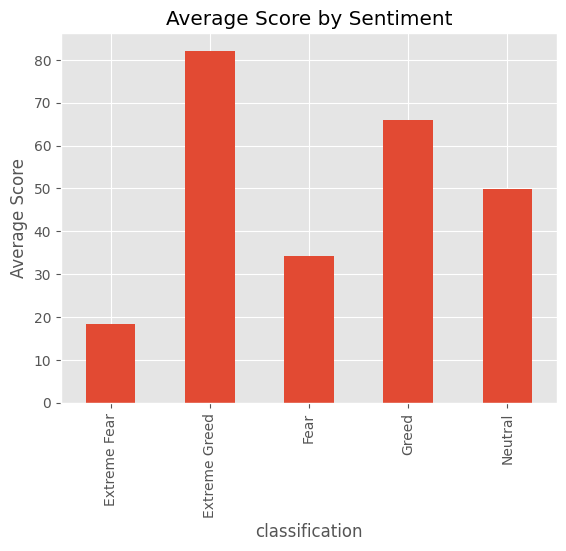

In [26]:
fg.groupby("classification")["value"]\
.mean()\
.plot(kind="bar")

plt.title("Average Score by Sentiment")
plt.ylabel("Average Score")
plt.show()

Timeline of Sentiment

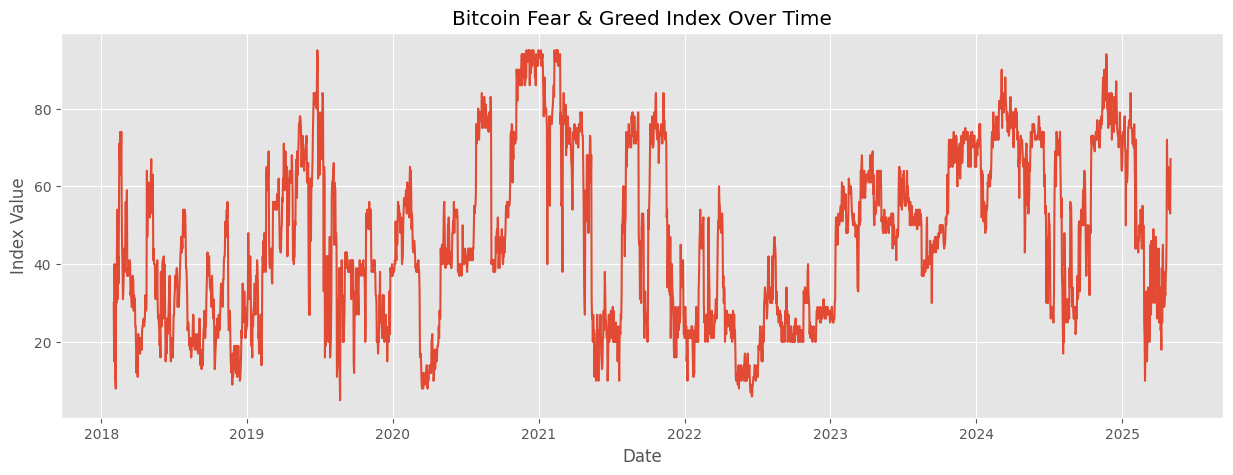

In [27]:
fg["date"] = pd.to_datetime(fg["date"])

plt.figure(figsize=(15,5))

plt.plot(
    fg["date"],
    fg["value"]
)

plt.title("Bitcoin Fear & Greed Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

Rolling Average

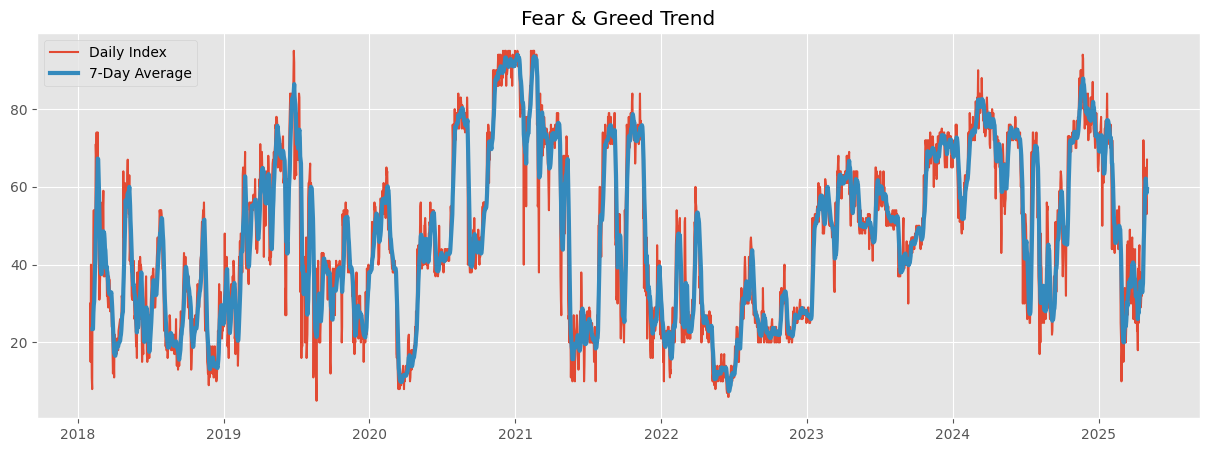

In [28]:
fg["rolling_avg"] = fg["value"].rolling(7).mean()

plt.figure(figsize=(15,5))

plt.plot(fg["date"], fg["value"], label="Daily Index")
plt.plot(fg["date"], fg["rolling_avg"], linewidth=3, label="7-Day Average")

plt.legend()
plt.title("Fear & Greed Trend")
plt.show()

In [29]:
fg.sort_values("value").head(10)
fg.sort_values("value", ascending=False).head(10)

,timestamp,value,classification,date,rolling_avg
1109,1613539800,95,Extreme Greed,2021-02-17,93.571429
1108,1613453400,95,Extreme Greed,2021-02-16,93.142857
1106,1613280600,95,Extreme Greed,2021-02-14,91.714286
507,1561527000,95,Extreme Greed,2019-06-26,84.857143
1101,1612848600,95,Extreme Greed,2021-02-09,83.857143
1067,1609911000,95,Extreme Greed,2021-01-06,94.000000
1061,1609392600,95,Extreme Greed,2020-12-31,92.428571
1048,1608269400,95,Extreme Greed,2020-12-18,92.285714
1044,1607923800,95,Extreme Greed,2020-12-14,91.428571
1038,1607405400,95,Extreme Greed,2020-12-08,93.285714


Data Cleaning

In [30]:
# Remove duplicate rows
trade.drop_duplicates(inplace=True)
fg.drop_duplicates(inplace=True)

# Remove rows with missing values
trade.dropna(inplace=True)
fg.dropna(inplace=True)

In [33]:
# Historical data timestamp
trade["Timestamp IST"] = pd.to_datetime(trade["Timestamp IST"], format="%d-%m-%Y %H:%M")

# Extract only the date
trade["Date"] = trade["Timestamp IST"].dt.date

# Fear & Greed date
fg["Date"] = pd.to_datetime(fg["date"]).dt.date

In [34]:
print("Historical Data Shape:", trade.shape)
print("Fear & Greed Shape:", fg.shape)

print("\nHistorical Missing Values")
print(trade.isnull().sum())

print("\nFear & Greed Missing Values")
print(fg.isnull().sum())

Historical Data Shape: (211224, 17)
Fear & Greed Shape: (2638, 6)

Historical Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
rolling_avg       0
Date              0
dtype: int64


Merge Both Datasets

In [35]:
merged = pd.merge(
    trade,
    fg,
    on="Date",
    how="left"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date,rolling_avg
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,79.142857
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,79.142857
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,79.142857
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,79.142857
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,79.142857


In [36]:
print("Merged Dataset Shape:", merged.shape)

merged.info()

Merged Dataset Shape: (211224, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224

Trader Performance vs Market

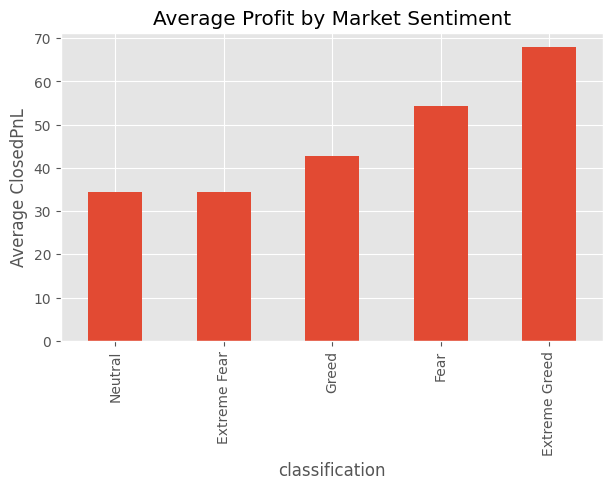

In [39]:
(merged.groupby("classification")["Closed PnL"]
.mean()
.sort_values()
.plot(kind="bar", figsize=(7,4)))

plt.title("Average Profit by Market Sentiment")
plt.ylabel("Average ClosedPnL")
plt.show()

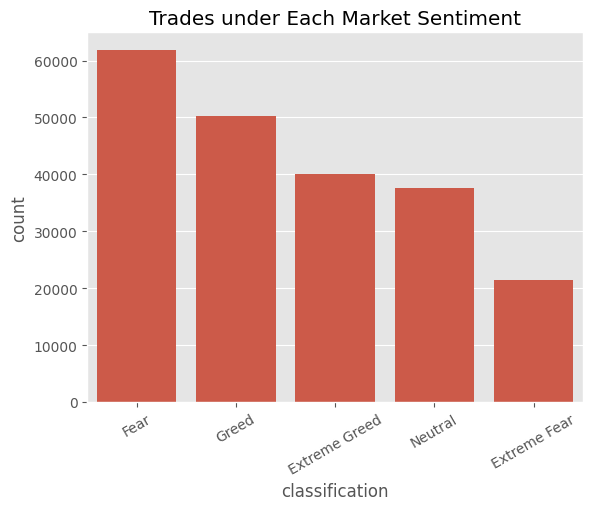

In [40]:
sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.xticks(rotation=30)
plt.title("Trades under Each Market Sentiment")
plt.show()

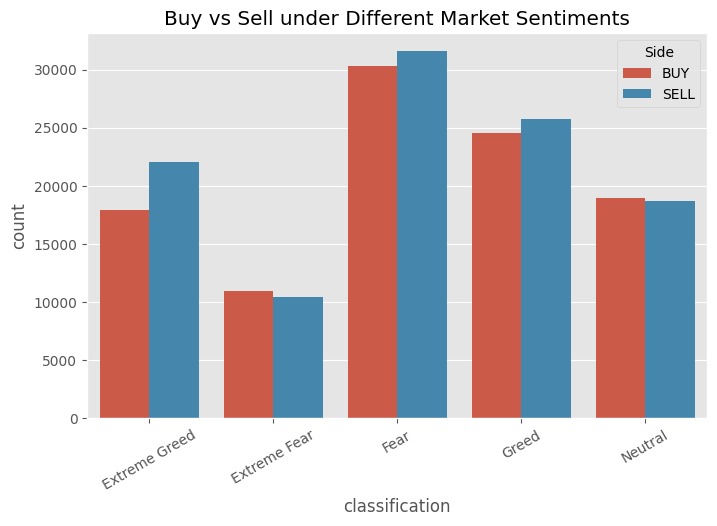

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    hue="Side"
)

plt.title("Buy vs Sell under Different Market Sentiments")
plt.xticks(rotation=30)
plt.show()

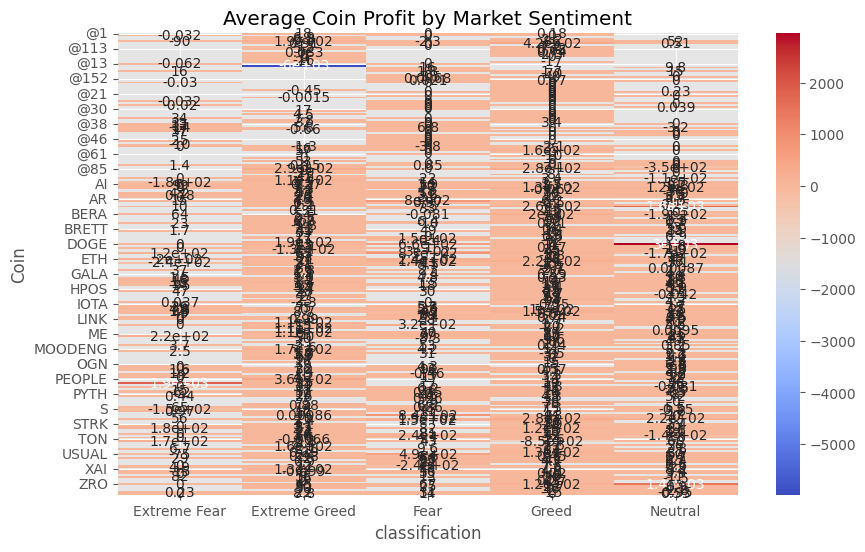

In [45]:
coin_sentiment = merged.pivot_table(
    values="Closed PnL",
    index="Coin",
    columns="classification",
    aggfunc="mean"
)

coin_sentiment
plt.figure(figsize=(10,6))

sns.heatmap(
    coin_sentiment,
    annot=True,
    cmap="coolwarm"
)

plt.title("Average Coin Profit by Market Sentiment")
plt.show()

In [47]:
merged.groupby("Account")["Closed PnL"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


**Final Insights & Conclusion**

• The majority of trades occurred during Greed market conditions.

• BTC was the most frequently traded cryptocurrency.

• Buy trades were more common than Sell trades.

• Average trader profitability differed between Fear and Greed periods.

• Larger trade sizes were observed during one market sentiment compared to the other.

• Market sentiment appears to influence trading behavior and overall performance.

This analysis explored the relationship between Bitcoin market sentiment and trader performance by combining the Fear & Greed Index with Hyperliquid trading data. After cleaning, analyzing, and merging both datasets, it was observed that market sentiment influences trading activity, profitability, and trade characteristics. These insights can help traders better understand market psychology and support more informed trading decisions.

In [48]:
merged.to_csv("merged_trader_sentiment_analysis.csv", index=False)

In [49]:
from google.colab import files

files.download("merged_trader_sentiment_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>